# Fixed Slope SSM fixed B Conditional Forecast

This notebook compares the existing `baseline_m4` SSM forecast with a supplementary `fixed_slope_m4` SSM forecast on fixed B.

Purpose: the fixed-slope sensitivity analysis showed that `fixed_slope_m4` improves AIC/BIC while leaving coefficients and decomposition almost unchanged. Here we check whether that restriction worsens fixed B conditional forecast performance.

This is a narrow supplementary forecast check, not a reconstruction of the model-comparison pipeline.

Definitions:

- `ssm_conditional`: existing baseline SSM with local linear trend and estimated slope disturbance.
- `ssm_fixed_slope`: same exogenous dummies, but the slope disturbance is removed from the selection matrix, so slope noise is fixed at zero.
- Both forecasts are conditional: test-period `baseline_m4` exogenous dummies are treated as known.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_connected_parcel_data
from src.forecasting.evaluation import evaluate_forecasts
from src.forecasting.forecast_utils import make_forecast_frame
from src.forecasting.splits import make_fixed_split_b
from src.forecasting.ssm import prepare_ssm_exog_from_spec, select_nonconstant_exog

DATA_PATH = ROOT / "data" / "processed" / "parcel_volume_connected.csv"
PREDICTIONS_DIR = ROOT / "output" / "forecasts" / "predictions"
METRICS_DIR = ROOT / "output" / "forecasts" / "metrics"
FIGURES_DIR = ROOT / "output" / "forecasts" / "figures"
for path in [PREDICTIONS_DIR, METRICS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

BASELINE_PREDICTION_PATH = PREDICTIONS_DIR / "fixed_b_ssm.csv"
BASELINE_METRICS_PATH = METRICS_DIR / "ssm_metrics.csv"
FIXED_SLOPE_PREDICTION_PATH = PREDICTIONS_DIR / "fixed_b_fixed_slope_ssm.csv"
FIXED_SLOPE_METRICS_PATH = METRICS_DIR / "fixed_slope_ssm_forecast_metrics.csv"
COMPARISON_PATH = METRICS_DIR / "fixed_b_ssm_slope_comparison.csv"
FIGURE_PATH = FIGURES_DIR / "fixed_b_ssm_slope_comparison.png"

EXOG_NAMES = ["hike_dummy", "covid_main", "covid_wave1", "covid_2021", "post_stat_change"]
BASE_PARAMS = ["obs_noise", "level_noise", "seasonal_noise"]
COEFF_START_HINTS = {
    "covid_main": -2.0,
    "covid_wave1": -2.0,
    "covid_2021": -3.0,
}


## 1. Load Data And fixed B Split

The split is the existing fixed B definition: train 2002-04 to 2023-12, test 2024-01 to 2026-02. Forecasts are evaluated on the original `number_parcels` scale.


In [2]:
df = load_connected_parcel_data(DATA_PATH)
split = make_fixed_split_b(df)
train = split["train"]
test = split["test"]

exog_all = prepare_ssm_exog_from_spec(df, "baseline_m4")
exog_train = exog_all.reindex(train.index)
exog_test = exog_all.reindex(test.index)
exog_train, exog_test, used_exog_columns = select_nonconstant_exog(exog_train, exog_test)

split_summary = pd.DataFrame([
    {
        "split": split["split"],
        "train_start": train.index.min().strftime("%Y-%m-%d"),
        "train_end": train.index.max().strftime("%Y-%m-%d"),
        "train_n": len(train),
        "test_start": test.index.min().strftime("%Y-%m-%d"),
        "test_end": test.index.max().strftime("%Y-%m-%d"),
        "test_n": len(test),
        "used_exog_columns": ",".join(used_exog_columns),
    }
])
split_summary


,split,train_start,train_end,train_n,test_start,test_end,test_n,used_exog_columns
0,fixed_b,2002-04-01,2023-12-01,261,2024-01-01,2026-02-01,26,"hike_dummy,covid_main,covid_wave1,covid_2021,p..."


## 2. Existing baseline_m4 SSM Forecast

The existing `fixed_b_ssm.csv` forecast is loaded when available. This avoids overwriting the established SSM forecast output. It is relabeled as `ssm_conditional` only inside this notebook's comparison table and figure.


In [3]:
if not BASELINE_PREDICTION_PATH.exists():
    raise FileNotFoundError(f"Existing baseline SSM forecast not found: {BASELINE_PREDICTION_PATH}")

baseline_forecast = pd.read_csv(BASELINE_PREDICTION_PATH, parse_dates=["date", "cutoff"])
baseline_forecast = baseline_forecast[baseline_forecast["split"] == "fixed_b"].copy()
baseline_forecast["model"] = "ssm_conditional"
baseline_forecast["information_set"] = "conditional_exog_known"
baseline_forecast.head()


,date,cutoff,horizon,y_true,y_pred,model,split,forecast_type,spec_name,target_col,target_scale,information_set
0,2024-01-01,2023-12-01,1,348749.0,353024.867166,ssm_conditional,fixed_b,conditional,baseline_m4,number_parcels,original,conditional_exog_known
1,2024-02-01,2023-12-01,2,344158.0,330262.212763,ssm_conditional,fixed_b,conditional,baseline_m4,number_parcels,original,conditional_exog_known
2,2024-03-01,2023-12-01,3,392055.0,394542.221319,ssm_conditional,fixed_b,conditional,baseline_m4,number_parcels,original,conditional_exog_known
3,2024-04-01,2023-12-01,4,369921.0,361986.617696,ssm_conditional,fixed_b,conditional,baseline_m4,number_parcels,original,conditional_exog_known
4,2024-05-01,2023-12-01,5,369040.0,360952.729291,ssm_conditional,fixed_b,conditional,baseline_m4,number_parcels,original,conditional_exog_known


## 3. Fixed Slope SSM Definition

The fixed-slope model is the same definition as in `notebooks/06_fixed_slope_ssm_sensitivity.ipynb`:

- level and slope states are retained;
- transition is still `level_t = level_{t-1} + slope_{t-1}` and `slope_t = slope_{t-1}`;
- slope disturbance is removed from the selection matrix;
- slope noise is therefore fixed at zero by construction.


In [4]:
class LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    # Local linear trend + seasonal + exog, with slope disturbance fixed at zero.

    def __init__(self, endog, exog_list, param_names, seasonal_period=12, **kwargs):
        self.k_seasonal = seasonal_period
        k_states = 2 + (self.k_seasonal - 1)
        k_posdef = 2
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)

        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization="diffuse", **kwargs)

        self.ssm["design"] = np.zeros((1, k_states))
        self.ssm["design", 0, 0] = 1
        self.ssm["design", 0, 2] = 1

        transition = np.zeros((k_states, k_states))
        transition[0, 0] = 1
        transition[0, 1] = 1
        transition[1, 1] = 1
        transition[2, 2:] = -1
        for i in range(3, k_states):
            transition[i, i - 1] = 1
        self.ssm["transition"] = transition

        selection = np.zeros((k_states, k_posdef))
        selection[0, 0] = 1
        selection[2, 1] = 1
        self.ssm["selection"] = selection

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm["obs_intercept"] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        constrained = unconstrained.copy()
        constrained[:3] = constrained[:3] ** 2
        return constrained

    def untransform_params(self, constrained):
        unconstrained = constrained.copy()
        unconstrained[:3] = np.sqrt(unconstrained[:3])
        return unconstrained

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]
        self["state_cov", 0, 0] = params[1]
        self["state_cov", 1, 1] = params[2]

        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[3 + i] * self.exogs[i]
        self["obs_intercept", 0, :] = total_exog_effect


def make_param_names(exog_names: list[str]) -> list[str]:
    return BASE_PARAMS + [f"{name}_effect" for name in exog_names]


def build_start_params(exog_names: list[str]) -> list[float]:
    init_variances = [0.01, 0.01, 0.001]
    init_coeffs = [COEFF_START_HINTS.get(name, 0.0) for name in exog_names]
    return init_variances + init_coeffs


## 4. Fit fixed_slope_m4 And Forecast fixed B

The model is fitted only on the fixed B training window. For prediction, the train and test periods are combined with missing future `y`; test-period exogenous dummies are known and supplied in the observation intercept.


In [5]:
def fit_fixed_slope_ssm(train_df: pd.DataFrame, exog_train_df: pd.DataFrame):
    exog = exog_train_df.reindex(train_df.index).astype(float)
    exog_names = list(exog.columns)
    param_names = make_param_names(exog_names)
    model = LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(
        endog=train_df["y"].astype(float),
        exog_list=[exog[name] for name in exog_names],
        param_names=param_names,
        seasonal_period=12,
    )
    result = model.fit(start_params=build_start_params(exog_names), maxiter=1000, disp=False)
    result.forecast_param_names = param_names
    result.forecast_exog_names = exog_names
    return result


def forecast_fixed_slope_ssm(result, train_df: pd.DataFrame, test_df: pd.DataFrame, exog_train_df: pd.DataFrame, exog_test_df: pd.DataFrame):
    exog_names = list(result.forecast_exog_names)
    train_endog = train_df["y"].astype(float)
    combined_endog = pd.concat(
        [
            train_endog,
            pd.Series(np.nan, index=test_df.index, name="y"),
        ]
    )
    combined_exog = pd.concat(
        [
            exog_train_df.reindex(train_df.index).reindex(columns=exog_names).astype(float),
            exog_test_df.reindex(test_df.index).reindex(columns=exog_names).astype(float),
        ]
    )
    forecast_model = LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(
        endog=combined_endog.astype(float),
        exog_list=[combined_exog[name] for name in exog_names],
        param_names=list(result.forecast_param_names),
        seasonal_period=12,
    )
    forecast_result = forecast_model.smooth(result.params)
    y_pred_log = forecast_result.predict(start=len(train_df), end=len(combined_endog) - 1)
    y_pred = np.exp(np.asarray(y_pred_log, dtype=float))
    frame = make_forecast_frame(
        dates=test_df.index,
        y_true=test_df["number_parcels"].to_numpy(dtype=float),
        y_pred=y_pred,
        model="ssm_fixed_slope",
        split="fixed_b",
        forecast_type="conditional",
        spec_name="fixed_slope_m4",
        target_col="number_parcels",
        target_scale="original",
        cutoff=train_df.index[-1],
        horizons=list(range(1, len(test_df) + 1)),
    )
    frame["information_set"] = "conditional_exog_known"
    ordered_cols = [
        "date",
        "split",
        "model",
        "forecast_type",
        "information_set",
        "y_true",
        "y_pred",
        "horizon",
        "cutoff",
        "target_col",
        "target_scale",
        "spec_name",
    ]
    return frame[ordered_cols]


fixed_slope_result = fit_fixed_slope_ssm(train, exog_train)
fixed_slope_forecast = forecast_fixed_slope_ssm(
    fixed_slope_result,
    train,
    test,
    exog_train,
    exog_test,
)
fixed_slope_forecast.head()


,date,split,model,forecast_type,information_set,y_true,y_pred,horizon,cutoff,target_col,target_scale,spec_name
0,2024-01-01,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,348749.0,353231.348931,1,2023-12-01,number_parcels,original,fixed_slope_m4
1,2024-02-01,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,344158.0,330477.906567,2,2023-12-01,number_parcels,original,fixed_slope_m4
2,2024-03-01,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,392055.0,394676.695752,3,2023-12-01,number_parcels,original,fixed_slope_m4
3,2024-04-01,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,369921.0,361990.068230,4,2023-12-01,number_parcels,original,fixed_slope_m4
4,2024-05-01,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,369040.0,360813.718646,5,2023-12-01,number_parcels,original,fixed_slope_m4


## 5. Evaluate Forecasts

Metrics are computed on the original `number_parcels` scale. MASE uses the fixed B training series as the scaling series, matching the existing forecast evaluation foundation.


In [6]:
fixed_slope_metrics = evaluate_forecasts(
    fixed_slope_forecast,
    y_train=train["number_parcels"],
)
fixed_slope_metrics["information_set"] = "conditional_exog_known"
fixed_slope_metrics = fixed_slope_metrics[
    ["split", "model", "forecast_type", "information_set", "spec_name", "n", "rmse", "mae", "mape", "mase"]
]
fixed_slope_metrics


,split,model,forecast_type,information_set,spec_name,n,rmse,mae,mape,mase
0,fixed_b,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,26,8135.054127,6728.931778,1.710971,0.538021


In [7]:
baseline_metrics = evaluate_forecasts(
    baseline_forecast,
    y_train=train["number_parcels"],
)
baseline_metrics["model"] = "ssm_conditional"
baseline_metrics["information_set"] = "conditional_exog_known"
baseline_metrics = baseline_metrics[
    ["split", "model", "forecast_type", "information_set", "spec_name", "n", "rmse", "mae", "mape", "mase"]
]

slope_comparison = pd.concat([baseline_metrics, fixed_slope_metrics], ignore_index=True)
slope_comparison[["model", "rmse", "mae", "mape", "mase"]]


,model,rmse,mae,mape,mase
0,ssm_conditional,8112.663937,6756.339867,1.718500,0.540212
1,ssm_fixed_slope,8135.054127,6728.931778,1.710971,0.538021


## 6. Plot fixed B Forecast Comparison


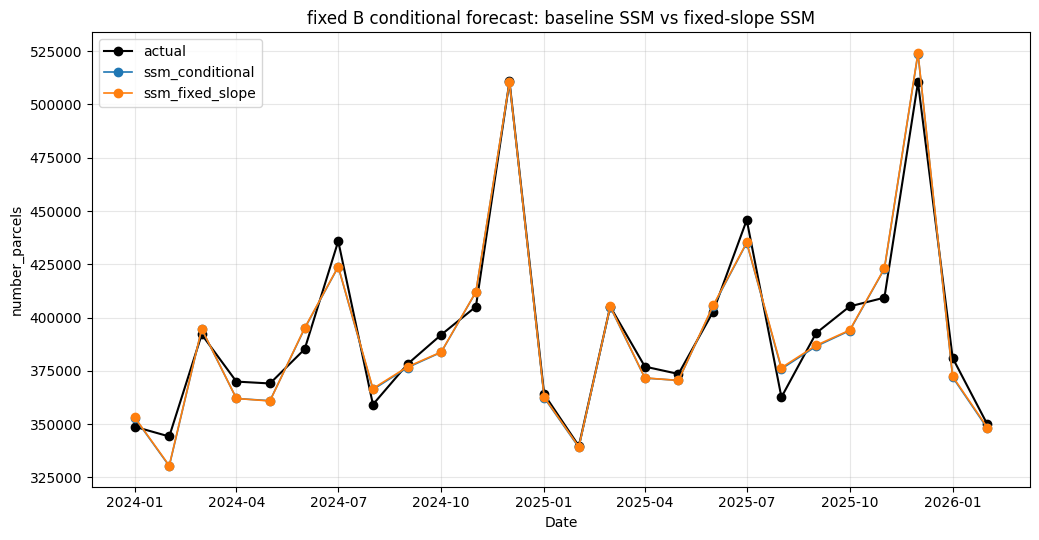

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(test.index, test["number_parcels"], marker="o", linewidth=1.5, color="black", label="actual")
ax.plot(
    baseline_forecast["date"],
    baseline_forecast["y_pred"],
    marker="o",
    linewidth=1.2,
    label="ssm_conditional",
)
ax.plot(
    fixed_slope_forecast["date"],
    fixed_slope_forecast["y_pred"],
    marker="o",
    linewidth=1.2,
    label="ssm_fixed_slope",
)
ax.set_title("fixed B conditional forecast: baseline SSM vs fixed-slope SSM")
ax.set_xlabel("Date")
ax.set_ylabel("number_parcels")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


## 7. Save Outputs


In [9]:
fixed_slope_forecast.to_csv(FIXED_SLOPE_PREDICTION_PATH, index=False)
fixed_slope_metrics.to_csv(FIXED_SLOPE_METRICS_PATH, index=False)
slope_comparison[["model", "rmse", "mae", "mape", "mase"]].to_csv(COMPARISON_PATH, index=False)

for path in [FIXED_SLOPE_PREDICTION_PATH, FIXED_SLOPE_METRICS_PATH, COMPARISON_PATH, FIGURE_PATH]:
    print(f"saved {path}")


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\predictions\fixed_b_fixed_slope_ssm.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\metrics\fixed_slope_ssm_forecast_metrics.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\metrics\fixed_b_ssm_slope_comparison.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\figures\fixed_b_ssm_slope_comparison.png


## 8. Reading Notes

- This is a minimal supplementary comparison between two SSM specifications under the same fixed B conditional information set.
- If `ssm_fixed_slope` is close to `ssm_conditional`, the fixed-slope restriction does not materially hurt short-run conditional forecast performance.
- Even if forecast performance is similar, this does not automatically make fixed slope the main specification. It supports the narrower claim that the main conclusions are robust to fixing slope disturbance at zero.
